Micro-Grad from Scratch

Step 1: Create a class that allows for addition, multiplication, track children nodes, and operation

In [1]:
class Value:
    def __init__(self,data, children=(), op='',label=''):
        self.data = data
        self.children = children
        self.op = op
        self.label = label

    def __repr__(self):
        return f'Value<{self.data}>'

    def __add__(self, other):
        return Value(self.data + other.data, (self,other), '+')

    def __mul__(self, other):
        return Value(self.data * other.data, (self,other), '*')

a=Value(2.0, label='a')
b=Value(3.0, label='b')
c=Value(4.0, label='c')

d=a*b;
d.label = 'd'

e=d+c;
e.label = 'e'





Step 2: Visualizing the Graph

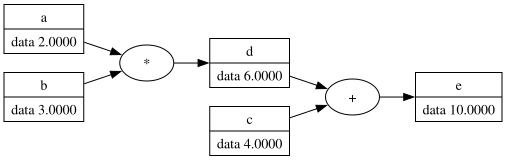

In [25]:
from graphviz import Digraph

def trace(root):
      """Walk backward from `root`, collecting every Value and every parent->child edge."""
      nodes, edges = set(), set()
      def build(v):
          if v not in nodes:
              nodes.add(v)
              for parent in v.children:
                  edges.add((parent, v))
                  build(parent)
      build(root)
      return nodes, edges

def draw_dot(root):
      dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # left-to-right layout
      nodes, edges = trace(root)
      for n in nodes:
          uid = str(id(n))
          # one rectangular node per Value, showing its data
          dot.node(name=uid, label=f"{n.label} | data {n.data:.4f}", shape='record')
          # if this Value was produced by an op, also draw a small op node
          if n.op:
              dot.node(name=uid + n.op, label=n.op)
              dot.edge(uid + n.op, uid)  # op feeds into the data
      for parent, child in edges:
          # parent's data feeds into child's op node
          dot.edge(str(id(parent)), str(id(child)) + child.op)
      return dot


draw_dot(e)

Step 3: Manual backpropogation.

Before backpropogating, we need to modify the Value class to accomodate for gradient

In [6]:
class Value:
    def __init__(self,data, children=(), op='',label=''):
        self.data = data
        self.children = children
        self.op = op
        self.label = label
        self.gradient = 0.0

    def __repr__(self):
        return f'Value<{self.data}>'

    def __add__(self, other):
        return Value(self.data + other.data, (self,other), '+')

    def __mul__(self, other):
        return Value(self.data * other.data, (self,other), '*')

a=Value(2.0, label='a')
b=Value(3.0, label='b')
c=Value(4.0, label='c')

d=a*b;
d.label = 'd'

e=d+c;
e.label = 'e'

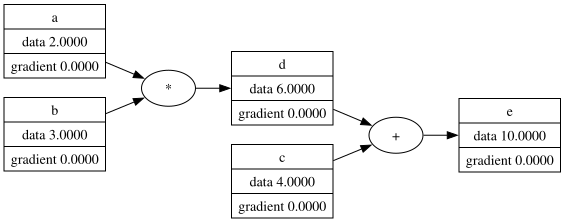

In [7]:
from graphviz import Digraph

def trace(root):
      """Walk backward from `root`, collecting every Value and every parent->child edge."""
      nodes, edges = set(), set()
      def build(v):
          if v not in nodes:
              nodes.add(v)
              for parent in v.children:
                  edges.add((parent, v))
                  build(parent)
      build(root)
      return nodes, edges

def draw_dot(root):
      dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # left-to-right layout
      nodes, edges = trace(root)
      for n in nodes:
          uid = str(id(n))
          # one rectangular node per Value, showing its data
          dot.node(name=uid, label=f"{n.label} | data {n.data:.4f} | gradient {n.gradient:.4f}", shape='record')
          # if this Value was produced by an op, also draw a small op node
          if n.op:
              dot.node(name=uid + n.op, label=n.op)
              dot.edge(uid + n.op, uid)  # op feeds into the data
      for parent, child in edges:
          # parent's data feeds into child's op node
          dot.edge(str(id(parent)), str(id(child)) + child.op)
      return dot


draw_dot(e)

Lets Start with De/De -> This boils down to 1.0 clearly. Hence e.gradient = 1.0

In [8]:
e.gradient = 1.0

Now lets work on De/Dd:

We know that e = c+d, hence De/Dd = D(c+d)/Dd -> 1.0. Therefore d.gradient = 1.0

In [9]:
d.gradient = 1.0

Now lets work on De/Dc:

We know that e = c+d, hence De/Dc = D(c+d)/Dc -> 1.0. Therefore c.gradient = 1.0

In [10]:
c.gradient = 1.0

Now lets work on De/Da:

This requires us to use the chain rule which says that: De/Da = Dd/Da * De/Dd

We know that De/Dd = 1.0

Dd/Da = D(a*b)/Da = b = 3.0

Therefore -> De/Da = 1.0 * 3.0 = 3.0

Hence, a.gradient = 3.0


In [11]:
a.gradient = 3.0

Now lets work on De/Db:

This requires us to use the chain rule which says that: De/Db = Dd/Db * De/Dd

We know that De/Dd = 1.0

Dd/Db = D(a*b)/Db = a = 2.0

Therefore -> De/Db = 1.0 * 2.0 = 2.0

Hence, b.gradient = 2.0

In [12]:
b.gradient = 2.0

Finally, lets re-visualize the graph with the gradients

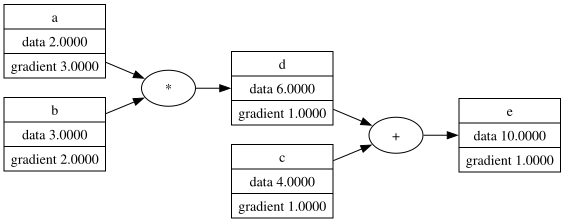

In [13]:
draw_dot(e)

Step 4: Modeling basic Neuron

We will assume 2 inputs going into 1 neuron to produce the output. We will assume the activation function to be tanh(x) = (e^2x -1)/(e^2x + 1)

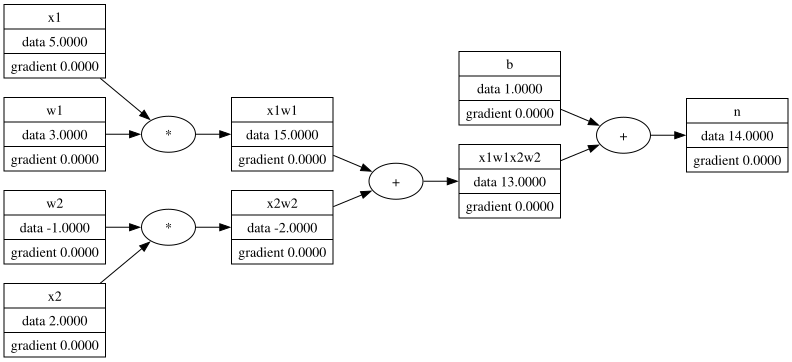

In [18]:
x1 = Value(5.0, label='x1')
x2 = Value (2.0, label='x2')

w1 = Value(3.0, label='w1')
w2 = Value(-1.0, label='w2')

b = Value(1.0, label='b')

x1w1=x1*w1; x1w1.label = 'x1w1'
x2w2=x2*w2; x2w2.label = 'x2w2'

x1w1x2w2= x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

n = x1w1x2w2 +b; n.label = 'n'

draw_dot(n)


Before implementing the activation function we need to ensure the class can accommodate it. Hence, we need to make some changes to the 'Value' Class

In [20]:
import math

class Value:
    def __init__(self,data, children=(), op='',label=''):
        self.data = data
        self.children = children
        self.op = op
        self.label = label
        self.gradient = 0.0

    def __repr__(self):
        return f'Value<{self.data}>'

    def __add__(self, other):
        return Value(self.data + other.data, (self,other), '+')

    def __mul__(self, other):
        return Value(self.data * other.data, (self,other), '*')

    def tanh(self):
        return Value(math.tanh(self.data), (self,), 'tanh')


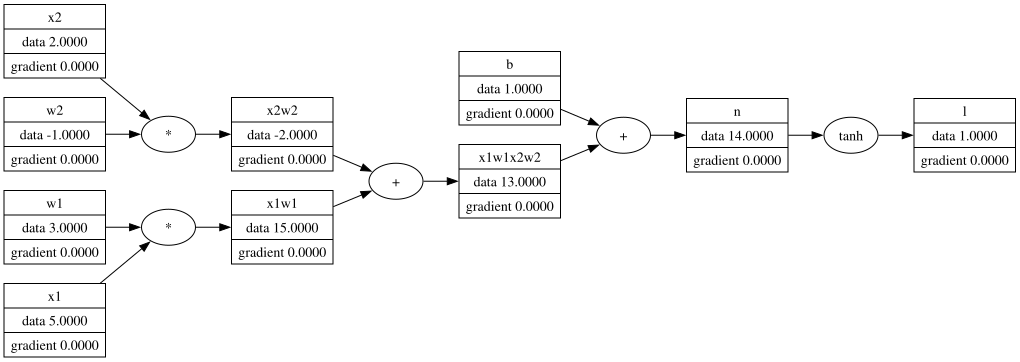

In [23]:
x1 = Value(5.0, label='x1')
x2 = Value (2.0, label='x2')

w1 = Value(3.0, label='w1')
w2 = Value(-1.0, label='w2')

b = Value(1.0, label='b')

x1w1=x1*w1; x1w1.label = 'x1w1'
x2w2=x2*w2; x2w2.label = 'x2w2'

x1w1x2w2= x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

n = x1w1x2w2 +b; n.label = 'n'

l = n.tanh(); l.label = 'l'

draw_dot(l)

Step 5: Implementing the backward function for each operation, instead of manually determining the gradient

We need the class to now accomodate the 'backward function' and at every operation within the class, the formula for the backward operation/gradient must be defined

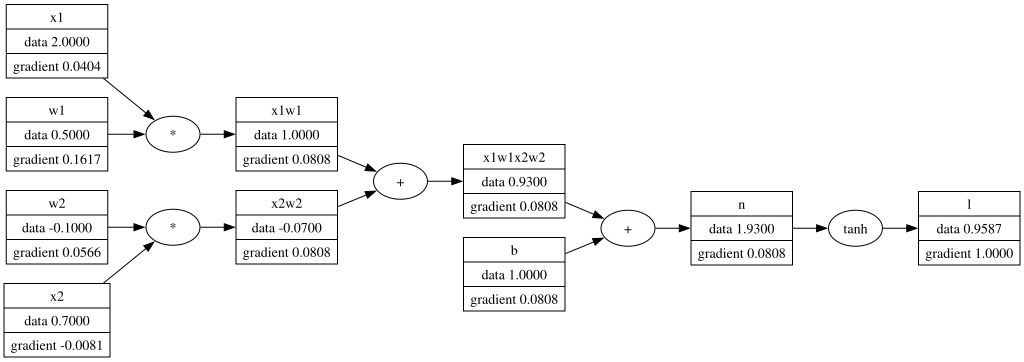

In [29]:
import math

class Value:
    def __init__(self,data, children=(), op='',label=''):
        self.data = data
        self.children = children
        self.op = op
        self.label = label
        self.gradient = 0.0
        self._backward = lambda: None

    def __repr__(self):
        return f'Value<{self.data}>'

    def __add__(self, other):
        out = Value(self.data + other.data, (self,other), '+')

        def _backward():

            self.gradient += out.gradient
            other.gradient += out.gradient

        out._backward = _backward

        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self,other), '*')

        def _backward():

            self.gradient += out.gradient * other.data
            other.gradient += out.gradient * self.data

        out._backward = _backward

        return out

    def tanh(self):
        out = Value(math.tanh(self.data), (self,), 'tanh')

        def _backward():

            self.gradient += (1-out.data**2) * out.gradient

        out._backward = _backward

        return out

#Example Below

x1 = Value(2.0, label='x1')
x2 = Value (0.7, label='x2')

w1 = Value(0.5, label='w1')
w2 = Value(-0.1, label='w2')

b = Value(1.0, label='b')

x1w1=x1*w1; x1w1.label = 'x1w1'
x2w2=x2*w2; x2w2.label = 'x2w2'

x1w1x2w2= x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

n = x1w1x2w2 +b; n.label = 'n'

l = n.tanh(); l.label = 'l'

l.gradient = 1.0
l._backward()
n._backward()
x1w1x2w2._backward()
b._backward()
x1w1._backward()
x2w2._backward()
x1._backward()
x2._backward()
w1._backward()
w2._backward()


draw_dot(l)


Now, instead of manually calling the backward expression for every node, we want it to automatically propogate through the network without us having to manually call